--- ÉTAPE 1 : CHARGEMENT ET SÉCURISATION DU DATASET ---

✓ Dataset chargé avec succès ! Dimensions : 9994 lignes, 21 colonnes

Nouvelles colonnes stratégiques créées : [Profit Margin, Order Year, Order Month, Order Month-Year]

--- ÉTAPE 2 : ANALYSE DES TENDANCES ET GÉOGRAPHIE ---


interactive(children=(Dropdown(description='Catégorie :', options=('All', 'Furniture', 'Office Supplies', 'Tec…

interactive(children=(IntSlider(value=10, description='Top N États:', max=25, min=5), Output()), _dom_classes=…


--- ÉTAPE 3 : ANALYSE DE LA RENTABILITÉ ET DIAGNOSTIC DES REMISES ---


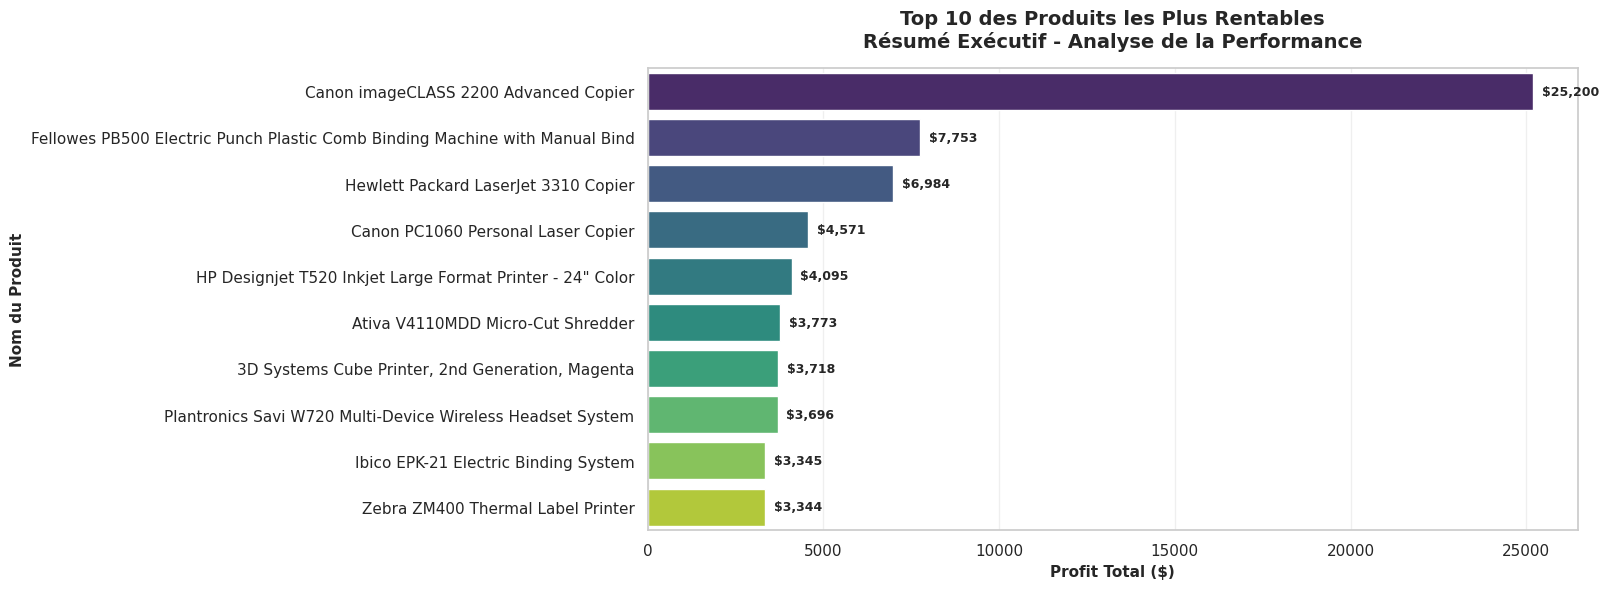

In [2]:
import time
import io
import os
import warnings
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display

# Désactivation des avertissements pour la clarté du rapport
warnings.filterwarnings('ignore')

# Configuration esthétique globale pour Seaborn et Matplotlib
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# =====================================================================
# 1. DÉFINITION ET PRÉPARATION DES DONNÉES
# =====================================================================
print("--- ÉTAPE 1 : CHARGEMENT ET SÉCURISATION DU DATASET ---")

nom_zip = 'archive.zip'

if os.path.exists(nom_zip):
    # Lecture directe du CSV à l'intérieur de l'archive ZIP chargée
    with zipfile.ZipFile(nom_zip, 'r') as z:
        liste_fichiers = z.namelist()
        csv_interne = [f for f in liste_fichiers if f.endswith('.csv')][0]
        with z.open(csv_interne) as f:
            df = pd.read_csv(io.BytesIO(f.read()), encoding='latin-1')
else:
    from google.colab import files
    print("Fichier archive.zip non trouvé. Veuillez le sélectionner :")
    file_loaded = files.upload()
    nom_zip = list(file_loaded.keys())[0]
    with zipfile.ZipFile(nom_zip, 'r') as z:
        liste_fichiers = z.namelist()
        csv_interne = [f for f in liste_fichiers if f.endswith('.csv')][0]
        with z.open(csv_interne) as f:
            df = pd.read_csv(io.BytesIO(f.read()), encoding='latin-1')

print(f"\n✓ Dataset chargé avec succès ! Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# 🧹 Nettoyage des doublons et gestion des valeurs manquantes
df = df.drop_duplicates()

if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

# 🕓 Correction des types de données
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# 🏗️ Ingénierie des fonctionnalités (Feature Engineering)
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

print("\nNouvelles colonnes stratégiques créées : [Profit Margin, Order Year, Order Month, Order Month-Year]")
print("="*80 + "\n")

# =====================================================================
# 2. ANALYSE EXPLORATOIRE APPROFONDIE (MATPLOTLIB INTERACTIF)
# =====================================================================
print("--- ÉTAPE 2 : ANALYSE DES TENDANCES ET GÉOGRAPHIE ---")

# Préparation des données de séries temporelles
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

# Graphique 1 : Tendances mensuelles dynamiques
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 5))
    if category == 'All':
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values,
                 marker='o', color='darkblue', linewidth=2, markersize=5)
        plt.title('Évolution des Ventes Mensuelles Globales (Toutes catégories)', fontsize=14, fontweight='bold')
    else:
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Date'], category_data['Sales'],
                 marker='o', color='teal', linewidth=2, markersize=5)
        plt.title(f'Évolution des Ventes Mensuelles - Catégorie : {category}', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=11)
    plt.ylabel('Ventes ($)', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

categories = ['All'] + list(df['Category'].unique())
category_dropdown = Dropdown(options=categories, value='All', description='Catégorie :')
interact(plot_monthly_sales, category=category_dropdown)

# Graphique 2 : Performance géographique
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(5, top_n * 0.4)))
    top_states = state_sales.tail(top_n)
    bars = plt.barh(range(len(top_states)), top_states.values, color='steelblue')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Ventes Totales ($)', fontsize=11)
    plt.ylabel('États', fontsize=11)
    plt.title(f'Top {top_n} des États par Performance de Ventes', fontsize=14, fontweight='bold')

    # CORRECTION ICI : Utilisation de np.max au lieu de max natif
    valeur_max = np.max(top_states.values)
    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + valeur_max * 0.01, i, f'${value:,.0f}', va='center', fontsize=9)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N États:')
interact(plot_top_states, top_n=top_n_slider)
print("="*80 + "\n")

# =====================================================================
# 3. COMMUNIQUER DES INFORMATIONS CIBLÉES (SEABORN)
# =====================================================================
print("--- ÉTAPE 3 : ANALYSE DE LA RENTABILITÉ ET DIAGNOSTIC DES REMISES ---")

# Graphique 3 : Top 10 Produits les plus rentables
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=product_profit.values, y=product_profit.index, palette='viridis', orient='h')
plt.title('Top 10 des Produits les Plus Rentables\nRésumé Exécutif - Analyse de la Performance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Profit Total ($)', fontsize=11, fontweight='bold')
plt.ylabel('Nom du Produit', fontsize=11, fontweight='bold')

# CORRECTION ICI : Utilisation de np.max au lieu de max natif
profit_max = np.max(product_profit.values)
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + profit_max * 0.01, i, f'${profit:,.0f}', va='center', fontweight='bold', fontsize=9)
plt.grid(axis='x', alpha=0.3)